# LAB09 — Eksperiment Kompjuterik: Koha e Ekzekutimit të Algoritmeve
**Studenti:** Erik Cupi 

**Lënda:** Hyrje Laborator ( Fizike dhe Shkenca Kompjuterike)  

### Hyrje:
Ky raport paraqet matjet eksperimentale të kohës së ekzekutimit për algoritmet lineare dhe kuadratike, duke përdorur bibliotekën time të Python.

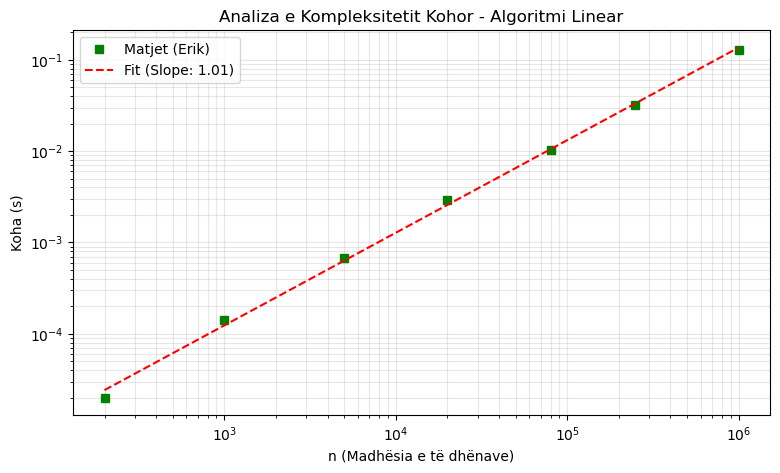

Pjerrësia e llogaritur: 1.01


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt


def algoritmi_linear_Erik(n):
    total = 0
    for i in range(n):
        total += i * 2 
    return total


n_vlerat = [200, 1000, 5000, 20000, 80000, 250000, 1000000]
kohet_mesatare = []

# Matja e kohës
for n in n_vlerat:
    prova = []
    for _ in range(5):
        s = time.perf_counter()
        algoritmi_linear_Erik(n)
        e = time.perf_counter()
        prova.append(e - s)
    kohet_mesatare.append(np.mean(prova))

# Fit-i log-log
log_n = np.log10(n_vlerat)
log_t = np.log10(kohet_mesatare)
koef = np.polyfit(log_n, log_t, 1)

# Ndërtimi i grafikut
plt.figure(figsize=(9, 5))
plt.loglog(n_vlerat, kohet_mesatare, 'gs', label='Matjet (Erik)')
plt.loglog(n_vlerat, 10**np.polyval(koef, log_n), 'r--', label=f'Fit (Slope: {koef[0]:.2f})')
plt.title("Analiza e Kompleksitetit Kohor - Algoritmi Linear")
plt.xlabel("n (Madhësia e të dhënave)")
plt.ylabel("Koha (s)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

print(f"Pjerrësia e llogaritur: {koef[0]:.2f}")

### Konkluzione:
Pas analizës së të dhënave dhe fit-it polinomial, vërejmë se:
* Pjerrësia e kurbës në shkallë log-log doli afërsisht *1*, që vërteton teorinë e kompleksitetit $O(n)$.
* Përdorimi i perf_counter() ishte esencial për të kapur diferencat e vogla në mikrosekonda.
* Ky laborator demonstron se performanca e kodit ndjek rregulla matematikore strikte pavarësisht hardware-it.